In [1]:
# plotting the results of the benchmark 
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd
import seaborn as sns
from matplotlib.ticker import LogLocator
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from math import pi

# replicate indices 
replicate_indices = [str(i).zfill(2) for i in range(1, 31)]


## Dataframe generation 

This extracts the runtime and resource usage for the 30 replicate runs and constructs a data frame saved to csv 

In [7]:
# initiating empty lists to store the values
# --- matlab ---
matlab_intensity_realtime_values = []
matlab_intensity_peak_rss_values = []
matlab_intensity_rchar_values = []
matlab_intensity_wchar_values = []
matlab_intensity_read_bytes_values = []
matlab_intensity_write_bytes_values = []
matlab_intensity_pmem_values = []
matlab_intensity_pcpu_values = []


matlab_alignment_realtime_values = []
matlab_alignment_peak_rss_values = []
matlab_alignment_rchar_values = []
matlab_alignment_wchar_values = []
matlab_alignment_read_bytes_values = []
matlab_alignment_write_bytes_values = []
matlab_alignment_pmem_values = []
matlab_alignment_pcpu_values = []

matlab_stitching_realtime_values = []
matlab_stitching_peak_rss_values = []
matlab_stitching_rchar_values = []
matlab_stitching_wchar_values = []
matlab_stitching_read_bytes_values = []
matlab_stitching_write_bytes_values = []
matlab_stitching_pmem_values = []
matlab_stitching_pcpu_values = []

matlab_count_realtime_values = []
matlab_count_peak_rss_values = []
matlab_count_rchar_values = []
matlab_count_wchar_values = []
matlab_count_read_bytes_values = []
matlab_count_write_bytes_values = []
matlab_count_pmem_values = []
matlab_count_pcpu_values = []

# --- nextflow ---
nextflow_intensity_realtime_values = []
nextflow_intensity_peak_rss_values = []
nextflow_intensity_rchar_values = []
nextflow_intensity_wchar_values = []
nextflow_intensity_read_bytes_values = []
nextflow_intensity_write_bytes_values = []
nextflow_intensity_pmem_values = []
nextflow_intensity_pcpu_values = []


nextflow_alignment_realtime_values = []
nextflow_alignment_peak_rss_values = []
nextflow_alignment_rchar_values = []
nextflow_alignment_wchar_values = []
nextflow_alignment_read_bytes_values = []
nextflow_alignment_write_bytes_values = []
nextflow_alignment_pmem_values = []
nextflow_alignment_pcpu_values = []


nextflow_stitching_realtime_values = []
nextflow_stitching_peak_rss_values = []
nextflow_stitching_rchar_values = []
nextflow_stitching_wchar_values = []
nextflow_stitching_read_bytes_values = []
nextflow_stitching_write_bytes_values = []
nextflow_stitching_pmem_values = []
nextflow_stitching_pcpu_values = []

nextflow_count_realtime_values = []
nextflow_count_peak_rss_values = []
nextflow_count_rchar_values = []
nextflow_count_wchar_values = []
nextflow_count_read_bytes_values = []
nextflow_count_write_bytes_values = []
nextflow_count_pmem_values = []
nextflow_count_pcpu_values = []


In [8]:
# aggregate data from matlab/replicate_[index]/process_intensity/ get the matlab_trace.log file and extract the realtime value.

#iterate over the list of strings for the index since they are 0 padded in the folder names
for i in replicate_indices:
    with open(f'matlab/replicate_{i}/process_intensity/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_intensity_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_intensity_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_intensity_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_intensity_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_intensity_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_intensity_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_intensity_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_intensity_pcpu_values.append(cpu_value)
    with open(f'matlab/replicate_{i}/process_align/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_alignment_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_alignment_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_alignment_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_alignment_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_alignment_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_alignment_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_alignment_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_alignment_pcpu_values.append(cpu_value)
    with open(f'matlab/replicate_{i}/process_stitch/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_stitching_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_stitching_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_stitching_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_stitching_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_stitching_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_stitching_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_stitching_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_stitching_pcpu_values.append(cpu_value)
    with open(f'matlab/replicate_{i}/process_count/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_count_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_count_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_count_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_count_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_count_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_count_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_count_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_count_pcpu_values.append(cpu_value)

In [9]:
# from the value arrays create a pandas datafram with the following columns: 
# process; realtime; peak_rss; software
# and the values in the process column should be 'intensity', 'alignment', 'stitching', 'count'
# the software column should be 'matlab' for the matlab values and 'nextflow' for the nextflow values

matlab_df = pd.DataFrame({
    'process': ['intensity'] * len(matlab_intensity_realtime_values) +
               ['alignment'] * len(matlab_alignment_realtime_values) +
               ['stitching'] * len(matlab_stitching_realtime_values) +
               ['count'] * len(matlab_count_realtime_values),
    'realtime': matlab_intensity_realtime_values +
                matlab_alignment_realtime_values +
                matlab_stitching_realtime_values +
                matlab_count_realtime_values,
    'peak_rss': matlab_intensity_peak_rss_values +
                matlab_alignment_peak_rss_values +
                matlab_stitching_peak_rss_values +
                matlab_count_peak_rss_values,
    'rchar': matlab_intensity_rchar_values +
             matlab_alignment_rchar_values +
             matlab_stitching_rchar_values +
             matlab_count_rchar_values,
    'wchar': matlab_intensity_wchar_values +
             matlab_alignment_wchar_values +
             matlab_stitching_wchar_values +
             matlab_count_wchar_values,
    'read_bytes': matlab_intensity_read_bytes_values +
                  matlab_alignment_read_bytes_values +
                  matlab_stitching_read_bytes_values +
                  matlab_count_read_bytes_values,
    'write_bytes': matlab_intensity_write_bytes_values +
                   matlab_alignment_write_bytes_values +
                   matlab_stitching_write_bytes_values +
                   matlab_count_write_bytes_values,
    'pmem': matlab_intensity_pmem_values +
            matlab_alignment_pmem_values +
            matlab_stitching_pmem_values +
            matlab_count_pmem_values,
    'pcpu': matlab_intensity_pcpu_values +
            matlab_alignment_pcpu_values +
            matlab_stitching_pcpu_values +
            matlab_count_pcpu_values, 
    'software': ['matlab'] * (len(matlab_intensity_realtime_values) +
                             len(matlab_alignment_realtime_values) +
                             len(matlab_stitching_realtime_values) +
                             len(matlab_count_realtime_values))
})



In [10]:
matlab_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,software
0,intensity,33871.0,1616856.0,98550442.0,183114877.0,4096.0,183414784.0,24.0,1781.0,matlab
1,intensity,33357.0,1596580.0,98550430.0,183114877.0,532480.0,183418880.0,24.0,1836.0,matlab
2,intensity,34107.0,1663488.0,98551219.0,183114878.0,8192.0,183414784.0,24.0,1788.0,matlab
3,intensity,32765.0,1615904.0,98042676.0,183114881.0,8192.0,183410688.0,24.0,1840.0,matlab
4,intensity,34082.0,1598552.0,98550455.0,183114881.0,8192.0,183414784.0,24.0,1769.0,matlab
...,...,...,...,...,...,...,...,...,...,...
115,count,149343.0,10866372.0,65443396.0,2190444.0,0.0,2600960.0,165.0,44.0,matlab
116,count,149634.0,10871796.0,67532283.0,2190442.0,0.0,2596864.0,166.0,45.0,matlab
117,count,149669.0,10861532.0,65445296.0,2190440.0,0.0,2588672.0,166.0,45.0,matlab
118,count,146100.0,10839892.0,65436556.0,2190444.0,0.0,2580480.0,165.0,46.0,matlab


In [13]:
# get the data from the work dir -- correct values --- 
# create df with columns: process; hash/id
nextflow_id_df = pd.DataFrame(columns=['replicate','process', 'hash/id'])
# fill the df with the values from the files by iterating over the replicates and processes
for i in replicate_indices:
    file_pattern = f'nextflow/replicate_{i}/pipeline_info/execution_trace_*.txt'
    file_list = glob.glob(file_pattern)
    if file_list:
        df = pd.read_csv(file_list[0], sep='\t')
        # Create rows to add
        rows_to_add = [
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)']['hash'].values[0]}
        ]
        
        # Use pd.concat to add rows
        nextflow_id_df = pd.concat([nextflow_id_df, pd.DataFrame(rows_to_add)], ignore_index=True)

In [14]:
nextflow_id_df

# adding two new empty columns to the dataframe 
nextflow_id_df['realtime'] = np.nan
nextflow_id_df['peak_rss'] = np.nan
nextflow_id_df['rchar'] = np.nan
nextflow_id_df['wchar'] = np.nan
nextflow_id_df['read_bytes'] = np.nan
nextflow_id_df['write_bytes'] = np.nan
nextflow_id_df['pmem'] = np.nan
nextflow_id_df['pcpu'] = np.nan


In [15]:
# now iterating over the  rows in the dataframe, getting into the work dir and from the hash in the dataframe into the right sub dir to finde there the trace file and add real time and peak rss to the dataframe for the specific hash 
for index, row in nextflow_id_df.iterrows():
    replicate = row['replicate']
    process = row['process']
    hash_id = row['hash/id']
    
    # Construct the path to the trace file with glob pattern to find the trace file in the right subdir
    trace_file_pattern = f'nextflow/replicate_{replicate}/work/{hash_id}*/.command.trace'
    trace_file_path = glob.glob(trace_file_pattern)
    if trace_file_path:
        with open(trace_file_path[0], 'r') as f:
            for line in f:
                if 'realtime' in line:
                    realtime_value = float(line.split('realtime=')[1].strip())
                    # get the row with the current replicate and add the realtime value to the realtime column
                    nextflow_id_df.at[index, 'realtime'] = realtime_value
                if 'peak_rss' in line:
                    peak_rss_value = float(line.split('peak_rss=')[1].strip())
                    nextflow_id_df.at[index, 'peak_rss'] = peak_rss_value
                if 'rchar' in line:
                    rchar_value = float(line.split('rchar=')[1].strip())
                    nextflow_id_df.at[index, 'rchar'] = rchar_value
                if 'wchar' in line:
                    wchar_value = float(line.split('wchar=')[1].strip())
                    nextflow_id_df.at[index, 'wchar'] = wchar_value
                if 'read_bytes' in line:
                    read_bytes_value = float(line.split('read_bytes=')[1].strip())
                    nextflow_id_df.at[index, 'read_bytes'] = read_bytes_value
                if 'write_bytes' in line:
                    write_bytes_value = float(line.split('write_bytes=')[1].strip())
                    nextflow_id_df.at[index, 'write_bytes'] = write_bytes_value
                if '%mem' in line:
                    mem_value = float(line.split('%mem=')[1].strip())
                    nextflow_id_df.at[index, 'pmem'] = mem_value
                if '%cpu' in line:
                    cpu_value = float(line.split('%cpu=')[1].strip())
                    nextflow_id_df.at[index, 'pcpu'] = cpu_value


In [16]:
nextflow_id_df

,replicate,process,hash/id,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu
0,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,d4/b78637,34914.0,1494476.0,265995630.0,3.121421e+08,8085504.0,3.174359e+08,23.0,1786.0
1,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,66/a2ebe6,91367.0,1549044.0,357167486.0,1.949282e+08,94208.0,2.002412e+08,22.0,5756.0
2,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,de/b125c7,162310.0,1868976.0,537681869.0,2.252291e+09,184320.0,2.257904e+09,24.0,1395.0
3,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1),de/530721,970581.0,14317624.0,441947545.0,1.869282e+06,53248.0,1.871872e+06,218.0,1014.0
4,02,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,c9/a63102,34971.0,1496744.0,266489989.0,3.121421e+08,12148736.0,3.174318e+08,23.0,1777.0
...,...,...,...,...,...,...,...,...,...,...,...
115,29,NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1),09/2cac63,976950.0,14429440.0,441947438.0,1.869282e+06,0.0,1.871872e+06,219.0,1014.0
116,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,5a/09cc31,34816.0,1454536.0,265998622.0,3.121421e+08,9113600.0,3.174359e+08,22.0,1801.0
117,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,56/5951e0,89233.0,1547740.0,356668699.0,1.949282e+08,73728.0,2.002412e+08,22.0,5783.0
118,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,66/d25ea8,160389.0,1920260.0,541366348.0,2.252291e+09,192512.0,2.257904e+09,26.0,1401.0


In [17]:
# replace the process names to be matched with the matlab df process names
nextflow_id_df['process'] = nextflow_id_df['process'].replace({
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)': 'intensity',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)': 'alignment',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)': 'stitching',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)': 'count'
})  



In [18]:
# combine both dataframe and write them to csv. 
# first drop hash column from nextflow_id_df
nextflow_id_df = nextflow_id_df.drop(columns=['hash/id'])
# add software column to nextflow_id_df with value 'nextflow'
nextflow_id_df['software'] = 'nextflow'
# concatenate the two dataframes
combined_df = pd.concat([matlab_df, nextflow_id_df], ignore_index=True)
# write the combined dataframe to csv
combined_df.to_csv('benchmark_results.csv', index=False)    


In [60]:
combined_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,software,replicate
90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN


## Plotting results for resource usage and scaling 


#### convert dataframe 

In [3]:

#read in the saved combinde dataframe from csv . 
raw_benchmark_df = pd.read_csv('/mnt/ssd/performance_benchmark/benchmark_results.csv')
raw_benchmark_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,software,replicate
0,intensity,33871.0,1616856.0,98550442.0,1.831149e+08,4096.0,1.834148e+08,24.0,1781.0,matlab,NaN
1,intensity,33357.0,1596580.0,98550430.0,1.831149e+08,532480.0,1.834189e+08,24.0,1836.0,matlab,NaN
2,intensity,34107.0,1663488.0,98551219.0,1.831149e+08,8192.0,1.834148e+08,24.0,1788.0,matlab,NaN
3,intensity,32765.0,1615904.0,98042676.0,1.831149e+08,8192.0,1.834107e+08,24.0,1840.0,matlab,NaN
4,intensity,34082.0,1598552.0,98550455.0,1.831149e+08,8192.0,1.834148e+08,24.0,1769.0,matlab,NaN
...,...,...,...,...,...,...,...,...,...,...,...
235,count,976950.0,14429440.0,441947438.0,1.869282e+06,0.0,1.871872e+06,219.0,1014.0,nextflow,29.0
236,intensity,34816.0,1454536.0,265998622.0,3.121421e+08,9113600.0,3.174359e+08,22.0,1801.0,nextflow,30.0
237,alignment,89233.0,1547740.0,356668699.0,1.949282e+08,73728.0,2.002412e+08,22.0,5783.0,nextflow,30.0
238,stitching,160389.0,1920260.0,541366348.0,2.252291e+09,192512.0,2.257904e+09,26.0,1401.0,nextflow,30.0


In [4]:
# convert realtime from miliseconds to seconds and peak_rss from bytes to gb 
benchmark_df = raw_benchmark_df.copy()
benchmark_df['realtime'] = benchmark_df['realtime'] / 60000
benchmark_df['peak_rss'] = benchmark_df['peak_rss'] / (1024 * 1024) # GB --> raw in KB
benchmark_df['read_bytes'] = benchmark_df['read_bytes'] / (1024 ) # KB --> raw in bytes
benchmark_df['write_bytes'] = benchmark_df['write_bytes'] / (1024 * 1024 * 1024) # GB --> raw in bytes
benchmark_df['pcpu'] = benchmark_df['pcpu'] / 10
benchmark_df['pmem'] = benchmark_df['pmem'] / 10
benchmark_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,software,replicate
0,intensity,0.564517,1.541954,98550442.0,1.831149e+08,4.0,0.170818,2.4,178.1,matlab,NaN
1,intensity,0.555950,1.522617,98550430.0,1.831149e+08,520.0,0.170822,2.4,183.6,matlab,NaN
2,intensity,0.568450,1.586426,98551219.0,1.831149e+08,8.0,0.170818,2.4,178.8,matlab,NaN
3,intensity,0.546083,1.541046,98042676.0,1.831149e+08,8.0,0.170815,2.4,184.0,matlab,NaN
4,intensity,0.568033,1.524498,98550455.0,1.831149e+08,8.0,0.170818,2.4,176.9,matlab,NaN
...,...,...,...,...,...,...,...,...,...,...,...
235,count,16.282500,13.760986,441947438.0,1.869282e+06,0.0,0.001743,21.9,101.4,nextflow,29.0
236,intensity,0.580267,1.387154,265998622.0,3.121421e+08,8900.0,0.295635,2.2,180.1,nextflow,30.0
237,alignment,1.487217,1.476040,356668699.0,1.949282e+08,72.0,0.186489,2.2,578.3,nextflow,30.0
238,stitching,2.673150,1.831303,541366348.0,2.252291e+09,188.0,2.102837,2.6,140.1,nextflow,30.0


In [5]:
# rename software
#summary_stats = benchmark_df.groupby(['software', 'process']).agg({'realtime': ['mean', 'std'], 'peak_rss': ['mean', 'std'], 'read_bytes': ['mean', 'std'], 'write_bytes': ['mean', 'std'], 'pcpu': ['mean', 'std'], 'pmem': ['mean', 'std']})
benchmark_df = benchmark_df.assign(software=benchmark_df['software'].replace({'matlab': 'NuMorph', 'nextflow': 'nf-core/lsmquant'}))
benchmark_df = benchmark_df.assign(software=benchmark_df['software'].replace({'matlab': 'NuMorph', 'nextflow': 'nf-core/lsmquant'}))
benchmark_df


,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,software,replicate
0,intensity,0.564517,1.541954,98550442.0,1.831149e+08,4.0,0.170818,2.4,178.1,NuMorph,NaN
1,intensity,0.555950,1.522617,98550430.0,1.831149e+08,520.0,0.170822,2.4,183.6,NuMorph,NaN
2,intensity,0.568450,1.586426,98551219.0,1.831149e+08,8.0,0.170818,2.4,178.8,NuMorph,NaN
3,intensity,0.546083,1.541046,98042676.0,1.831149e+08,8.0,0.170815,2.4,184.0,NuMorph,NaN
4,intensity,0.568033,1.524498,98550455.0,1.831149e+08,8.0,0.170818,2.4,176.9,NuMorph,NaN
...,...,...,...,...,...,...,...,...,...,...,...
235,count,16.282500,13.760986,441947438.0,1.869282e+06,0.0,0.001743,21.9,101.4,nf-core/lsmquant,29.0
236,intensity,0.580267,1.387154,265998622.0,3.121421e+08,8900.0,0.295635,2.2,180.1,nf-core/lsmquant,30.0
237,alignment,1.487217,1.476040,356668699.0,1.949282e+08,72.0,0.186489,2.2,578.3,nf-core/lsmquant,30.0
238,stitching,2.673150,1.831303,541366348.0,2.252291e+09,188.0,2.102837,2.6,140.1,nf-core/lsmquant,30.0


##### Summary statistics

In [6]:
# get the summary statistics for the benchmark df
summary_stats = benchmark_df.groupby(['software', 'process']).agg({'realtime': ['mean', 'std'], 'peak_rss': ['mean', 'std'], 'read_bytes': ['mean', 'std'], 'write_bytes': ['mean', 'std'], 'pcpu': ['mean', 'std'], 'pmem': ['mean', 'std']})
summary_stats

realtime             peak_rss            \
                                 mean       std       mean       std   
software         process                                               
NuMorph          alignment   1.433257  0.017164   1.456720  0.065752   
                 count       2.486864  0.026738  10.366919  0.025340   
                 intensity   0.558350  0.009421   1.531586  0.020505   
                 stitching   1.279201  0.012407   1.775741  0.045576   
nf-core/lsmquant alignment   1.500017  0.012358   1.473065  0.013047   
                 count      16.110229  0.153318  13.745378  0.174636   
                 intensity   0.579771  0.005239   1.409906  0.025333   
                 stitching   2.693898  0.023612   1.806659  0.031424   

                             read_bytes              write_bytes            \
                                   mean          std        mean       std   
software         process                                                     
NuMorph          alignment     0.000000     0.000000    0.016109  0.000013   
                 count         0.000000     0.000000    0.002411  0.000011   
                 intensity    24.933333    93.588584    0.170819  0.000008   
                 stitching    37.466667     3.059562    0.966284  0.000011   
nf-core/lsmquant alignment    67.866667    55.010804    0.186489  0.000000   
                 count       229.200000   701.530268    0.001743  0.000000   
                 intensity  6464.933333  5692.686045    0.295634  0.000002   
                 stitching   151.200000    52.168427    2.102837  0.000002   

                                  pcpu                 pmem            
                                  mean       std       mean       std  
software         process                                               
NuMorph          alignment  597.200000  4.286788   2.236667  0.049013  
                 count        4.476667  0.081720  16.540000  0.067466  
                 intensity  181.506667  3.489090   2.403333  0.041384  
                 stitching  142.433333  0.715510   2.480000  0.168973  
nf-core/lsmquant alignment  577.833333  2.377674   2.180000  0.055086  
                 count      101.426667  0.044978  21.923333  0.277530  
                 intensity  179.286667  1.073741   2.253333  0.050742  
                 stitching  140.383333  0.547775   2.600000  0.143839

### Plotting resource usage

In [ ]:
## color style for the plots
palette = {
    "NuMorph": "#a6cee3",
    "nf-core/lsmquant": "#4daf4a"
}

#### Boxplots al processes together

/tmp/ipykernel_1344194/295898864.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bot.set_xticklabels(benchmark_df['process'].unique(), fontsize=12, fontweight="bold")
/tmp/ipykernel_1344194/295898864.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bot.set_xticklabels(benchmark_df['process'].unique(), fontsize=12, fontweight="bold")
/tmp/ipykernel_1344194/295898864.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(title="software", loc="upper left")


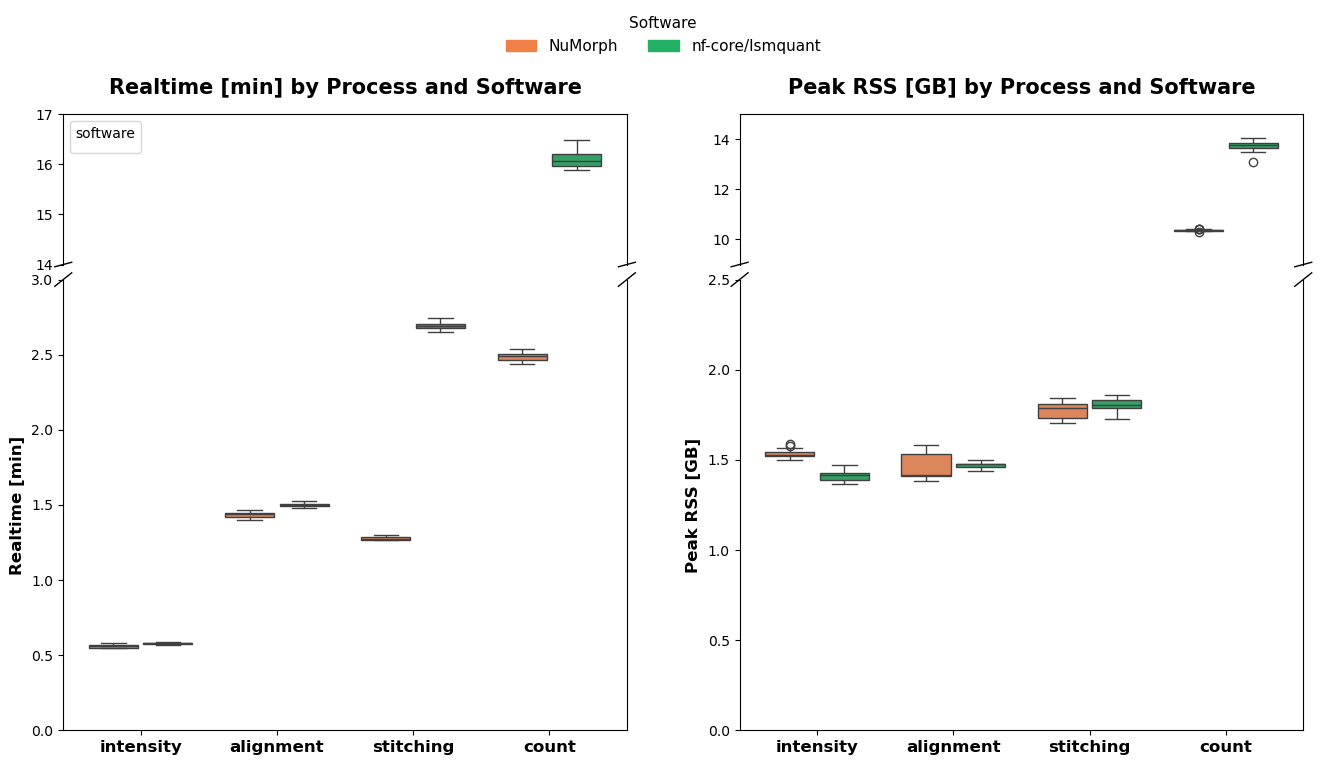

In [25]:

fig, axes = plt.subplots(2, 2, figsize=(16, 8),
                          gridspec_kw={"height_ratios": [1, 3], "hspace": 0.05})

for col, (y_col, y_label, y_lims_top, y_lims_bot) in enumerate([
    ("realtime",  "Realtime [min]", (14, 17), (0, 3)),
    ("peak_rss",  "Peak RSS [GB]",      (9, 15),    (0, 2.5)),
]):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    # Plot on both axes
    sns.boxplot(data=benchmark_df, x='process', y=y_col, hue='software', ax=ax_top, legend=False, palette=palette, gap=0.1)
    sns.boxplot(data=benchmark_df, x='process', y=y_col, hue='software', ax=ax_bot, legend=False, palette=palette, gap=0.1)

    # Set y limits to zoom into each range
    ax_top.set_ylim(*y_lims_top)
    ax_bot.set_ylim(*y_lims_bot)

    # Hide the x-axis on top, y-axis label only on bottom
    ax_top.set_xlabel("")
    ax_top.set_xticklabels([])
    ax_top.set_ylabel("")
    ax_bot.set_ylabel(y_label, va="center", labelpad=10, fontsize=12, fontweight="bold")
    ax_bot.set_xlabel("")
    #ax_bot.set_xlabel("Process", labelpad=10, fontsize=12, fontweight="bold")
    ax_bot.set_xticklabels(benchmark_df['process'].unique(), fontsize=12, fontweight="bold")
    ax_top.set_title(f"{y_label.split(' (')[0]} by Process and Software", fontsize=15, pad=15, fontweight="bold")

    # Broken axis cosmetics — hide inner spines
    ax_top.spines["bottom"].set_visible(False)
    ax_bot.spines["top"].set_visible(False)
    ax_top.tick_params(bottom=False)

    # Draw diagonal break marks
    d = 0.015
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1-d, 1+d), (-d, +d), **kwargs)
    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (1-d, 1+d), **kwargs)
    ax_bot.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# Move legend to top-left plot
axes[0, 0].legend(title="software", loc="upper left")

handles = [
    plt.matplotlib.patches.Patch(color=palette[s], label=s)
    for s in benchmark_df['software'].unique()
]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=11,
    title_fontsize=11,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
)

#plt.tight_layout()
plt.show()

#### Bar plots for all processes

/tmp/ipykernel_1344194/3215105620.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(benchmark_df['process'].unique(), fontsize=12, fontweight="bold")
/tmp/ipykernel_1344194/3215105620.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(benchmark_df['process'].unique(), fontsize=12, fontweight="bold")
/tmp/ipykernel_1344194/3215105620.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(title="Software", loc="upper left")


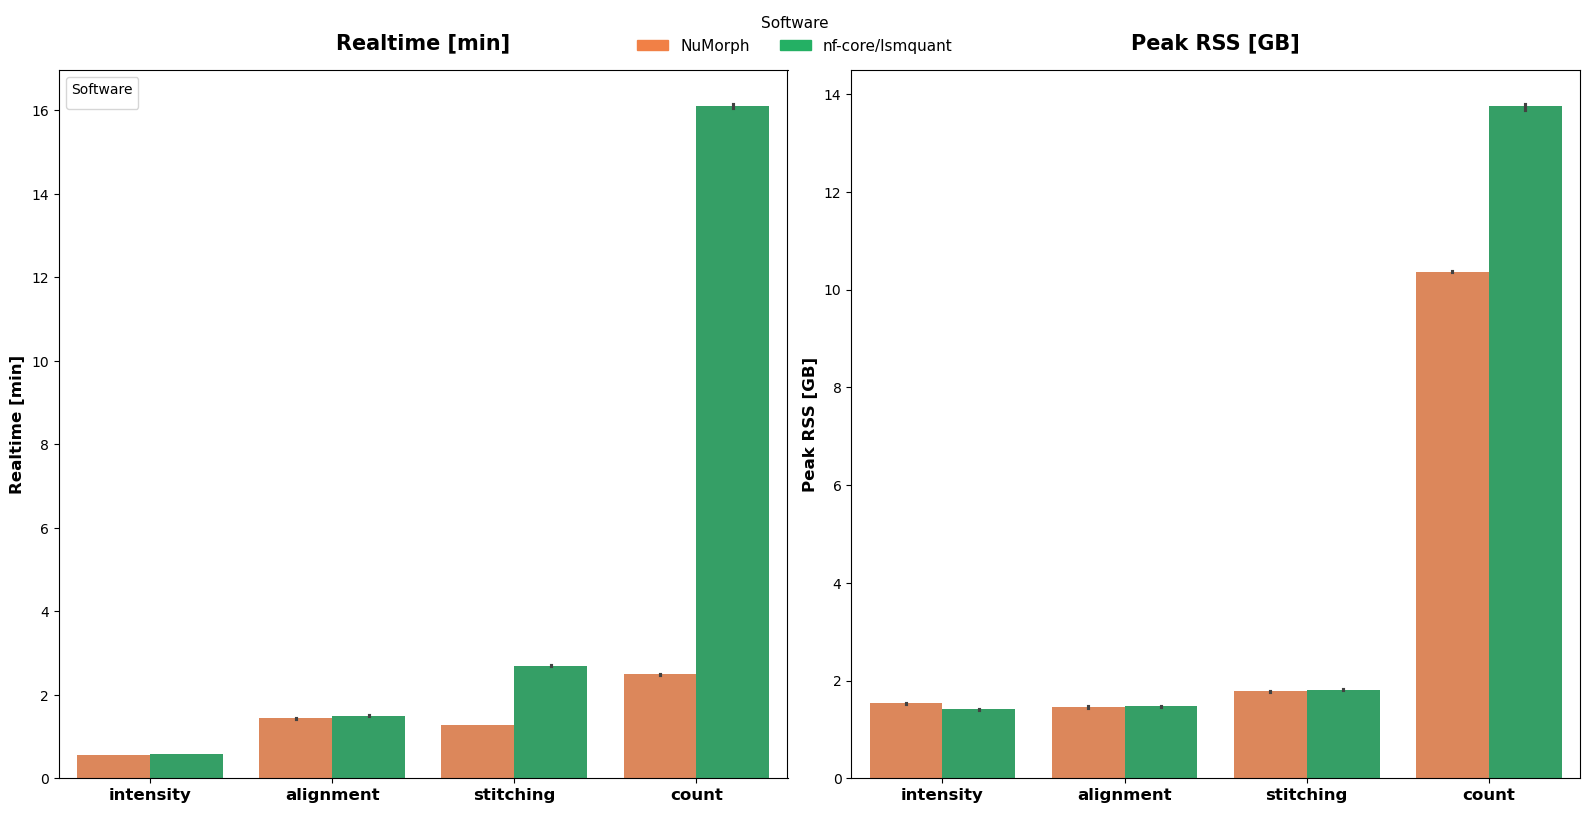

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(data=benchmark_df, x='process', y='realtime', hue='software', legend=False, palette=palette, ax=axs[0])
sns.barplot(data=benchmark_df, x='process', y='peak_rss', hue='software', legend=False, palette=palette, ax=axs[1])

axs[0].set_title("Realtime [min]", fontsize=15, pad=15, fontweight="bold")
axs[1].set_title("Peak RSS [GB]", fontsize=15, pad=15, fontweight="bold")

axs[0].set_xlabel("")
axs[1].set_xlabel("")
axs[0].set_ylabel("Realtime [min]", va="center", labelpad=10, fontsize=12, fontweight="bold")
axs[1].set_ylabel("Peak RSS [GB]", va="center", labelpad=10, fontsize=12, fontweight="bold")
axs[0].set_xticklabels(benchmark_df['process'].unique(), fontsize=12, fontweight="bold")
axs[1].set_xticklabels(benchmark_df['process'].unique(), fontsize=12, fontweight="bold")    
axs[0].legend(title="Software", loc="upper left")
handles = [
    plt.matplotlib.patches.Patch(color=palette[s], label=s)
    for s in benchmark_df['software'].unique()
]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=11,
    title_fontsize=11,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
)
plt.tight_layout()
plt.show()


#### Box plots for all individuall processes 

/tmp/ipykernel_1344194/3716286932.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


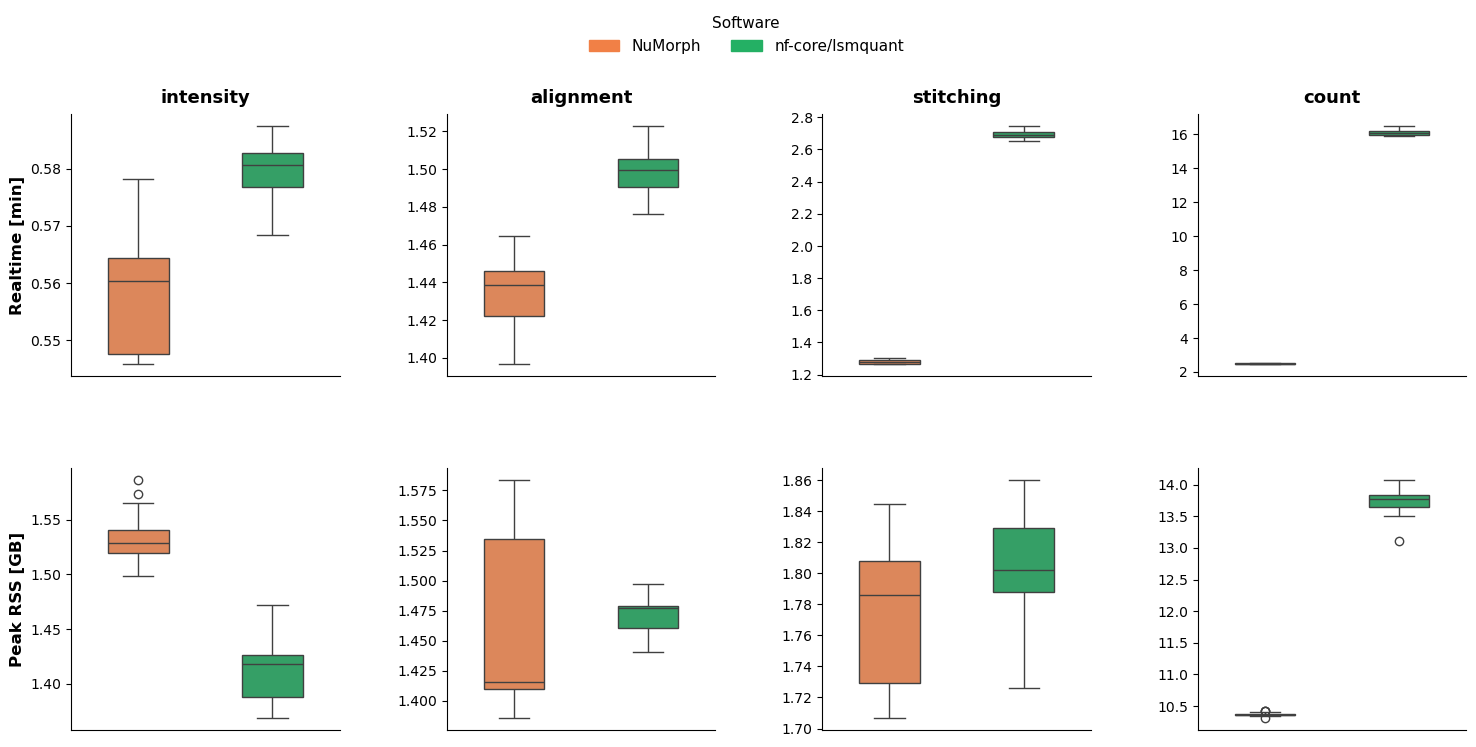

In [24]:



processes = benchmark_df['process'].unique()  # ['intensity', 'alignment', 'stitching', 'count']
metrics = [
    ("realtime",  "Realtime [min]"),
    ("peak_rss",  "Peak RSS [GB]"),
]

fig, axes = plt.subplots(
    nrows=2, ncols=4,
    figsize=(18, 8),
    gridspec_kw={"hspace": 0.35, "wspace": 0.4}
)

for row, (y_col, y_label) in enumerate(metrics):
    for col, process in enumerate(processes):
        ax = axes[row, col]

        df_sub = benchmark_df[benchmark_df['process'] == process]

        sns.boxplot(
            data=df_sub,
            x='software',
            y=y_col,
            hue='software',
            ax=ax,
            palette=palette,
            legend=False,
            gap=0.1,
            width=0.5,
        )

        # Title only on top row
        if row == 0:
            ax.set_title(process, fontsize=13, fontweight="bold", pad=8)

        # Y-axis label only on leftmost column
        if col == 0:
            ax.set_ylabel(y_label, fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.set_xticks([])  # remove x tick labels — legend handles software identity

        ax.tick_params(axis='y', labelsize=10)
        ax.spines[["top", "right"]].set_visible(False)

# Single shared legend — pull handles from any axis
handles = [
    plt.matplotlib.patches.Patch(color=palette[s], label=s)
    for s in benchmark_df['software'].unique()
]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=11,
    title_fontsize=11,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
)

fig.suptitle("")  # clear any auto title
plt.tight_layout()
plt.show()

#### combined bar plot and box plot 

/tmp/ipykernel_2403153/2156262793.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(processes, fontsize=16)
/tmp/ipykernel_2403153/2156262793.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(processes, fontsize=16)


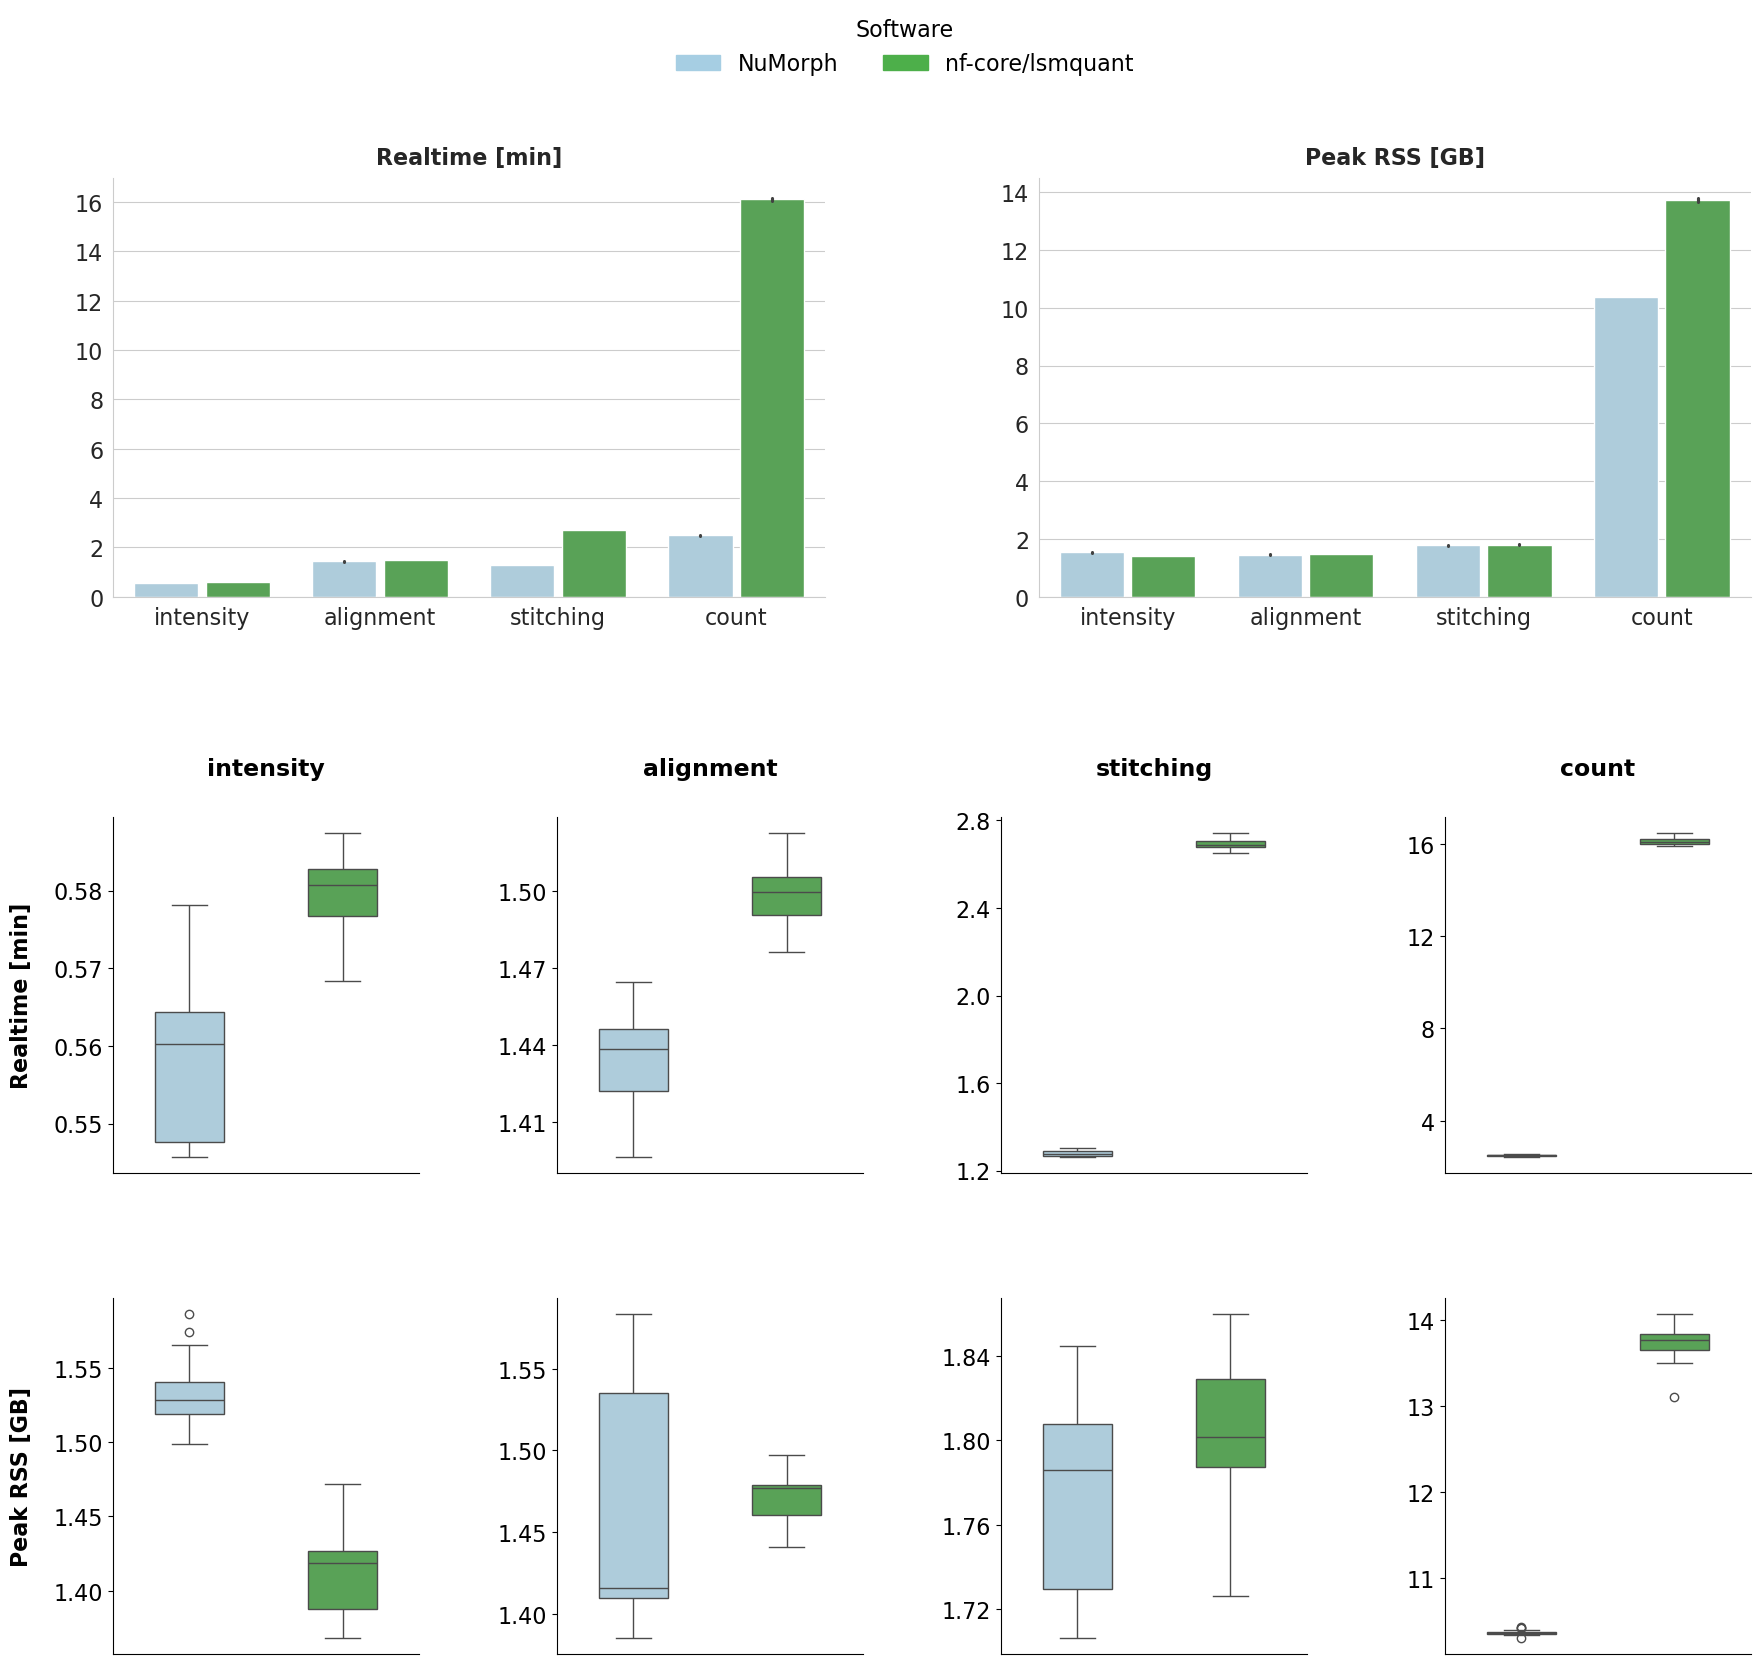

In [13]:
processes = benchmark_df['process'].unique()
metrics = [
    ("realtime", "Realtime [min]"),
    ("peak_rss",  "Peak RSS [GB]"),
]

fig = plt.figure(figsize=(18, 18))

gs_outer = GridSpec(2, 1, figure=fig, hspace=0.35,
                    top=0.88, bottom=0.06, left=0.06, right=0.97, height_ratios=[1, 2])

gs_bar   = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[0], wspace=0.3)
gs_box   = GridSpecFromSubplotSpec(2, 4, subplot_spec=gs_outer[1],
                                   wspace=0.45, hspace=0.35)

# ── Row 1: 2 bar plots ──────────────────────────────────────────────────────
with sns.axes_style("whitegrid"):
    bar_axes = [fig.add_subplot(gs_bar[0, i]) for i in range(2)]

    for ax, (y_col, y_label) in zip(bar_axes, metrics):

        sns.barplot(
            data=benchmark_df, x='process', y=y_col,
            hue='software', legend=False,
            palette=palette, ax=ax, gap=0.1
        )
        ax.set_title(y_label, fontsize=16, fontweight="bold", pad=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
        #ax.set_ylabel(y_label, fontsize=12, fontweight="bold", labelpad=10)
        ax.yaxis.set_tick_params(labelsize=16)
        ax.set_xticklabels(processes, fontsize=16)
        ax.spines[["top", "right"]].set_visible(False)

# ── Row 2 : 2×4 boxplot grid ─────────────────────────────────────────────
# Box plot axes inside gs_box

#with sns.axes_style("whitegrid"):
box_axes = [[fig.add_subplot(gs_box[row, col])
            for col in range(4)]
            for row in range(2)]

for row, (y_col, y_label) in enumerate(metrics):
    for col, process in enumerate(processes):
        ax = box_axes[row][col]
        df_sub = benchmark_df[benchmark_df['process'] == process]

        sns.boxplot(
            data=df_sub, x='software', y=y_col,
            hue='software', ax=ax,
            palette=palette, legend=False,
            gap=0.1, width=0.5,
        )
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))

        # Column title only on top row
        if row == 0:
            ax.set_title(process, fontsize=17, fontweight="bold", pad=30)

        # Y-axis label only on leftmost column
        ax.set_ylabel(y_label if col == 0 else "",
                    fontsize=16, fontweight="bold", labelpad=15)
        ax.set_xlabel("")
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=16)
        ax.spines[["top", "right"]].set_visible(False)

# ── Single shared legend at the top ─────────────────────────────────────────
handles = [mpatches.Patch(color=palette[s], label=s)
           for s in benchmark_df['software'].unique()]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=16,
    title_fontsize=16,
    bbox_to_anchor=(0.5, 0.98),
    frameon=False,
)

# Save figurer
plt.savefig("resource_usage_testdataset.png", dpi=300, bbox_inches="tight",
            facecolor="white")

plt.show()

#### Plot other monitored resources



/tmp/ipykernel_2403153/3925859933.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


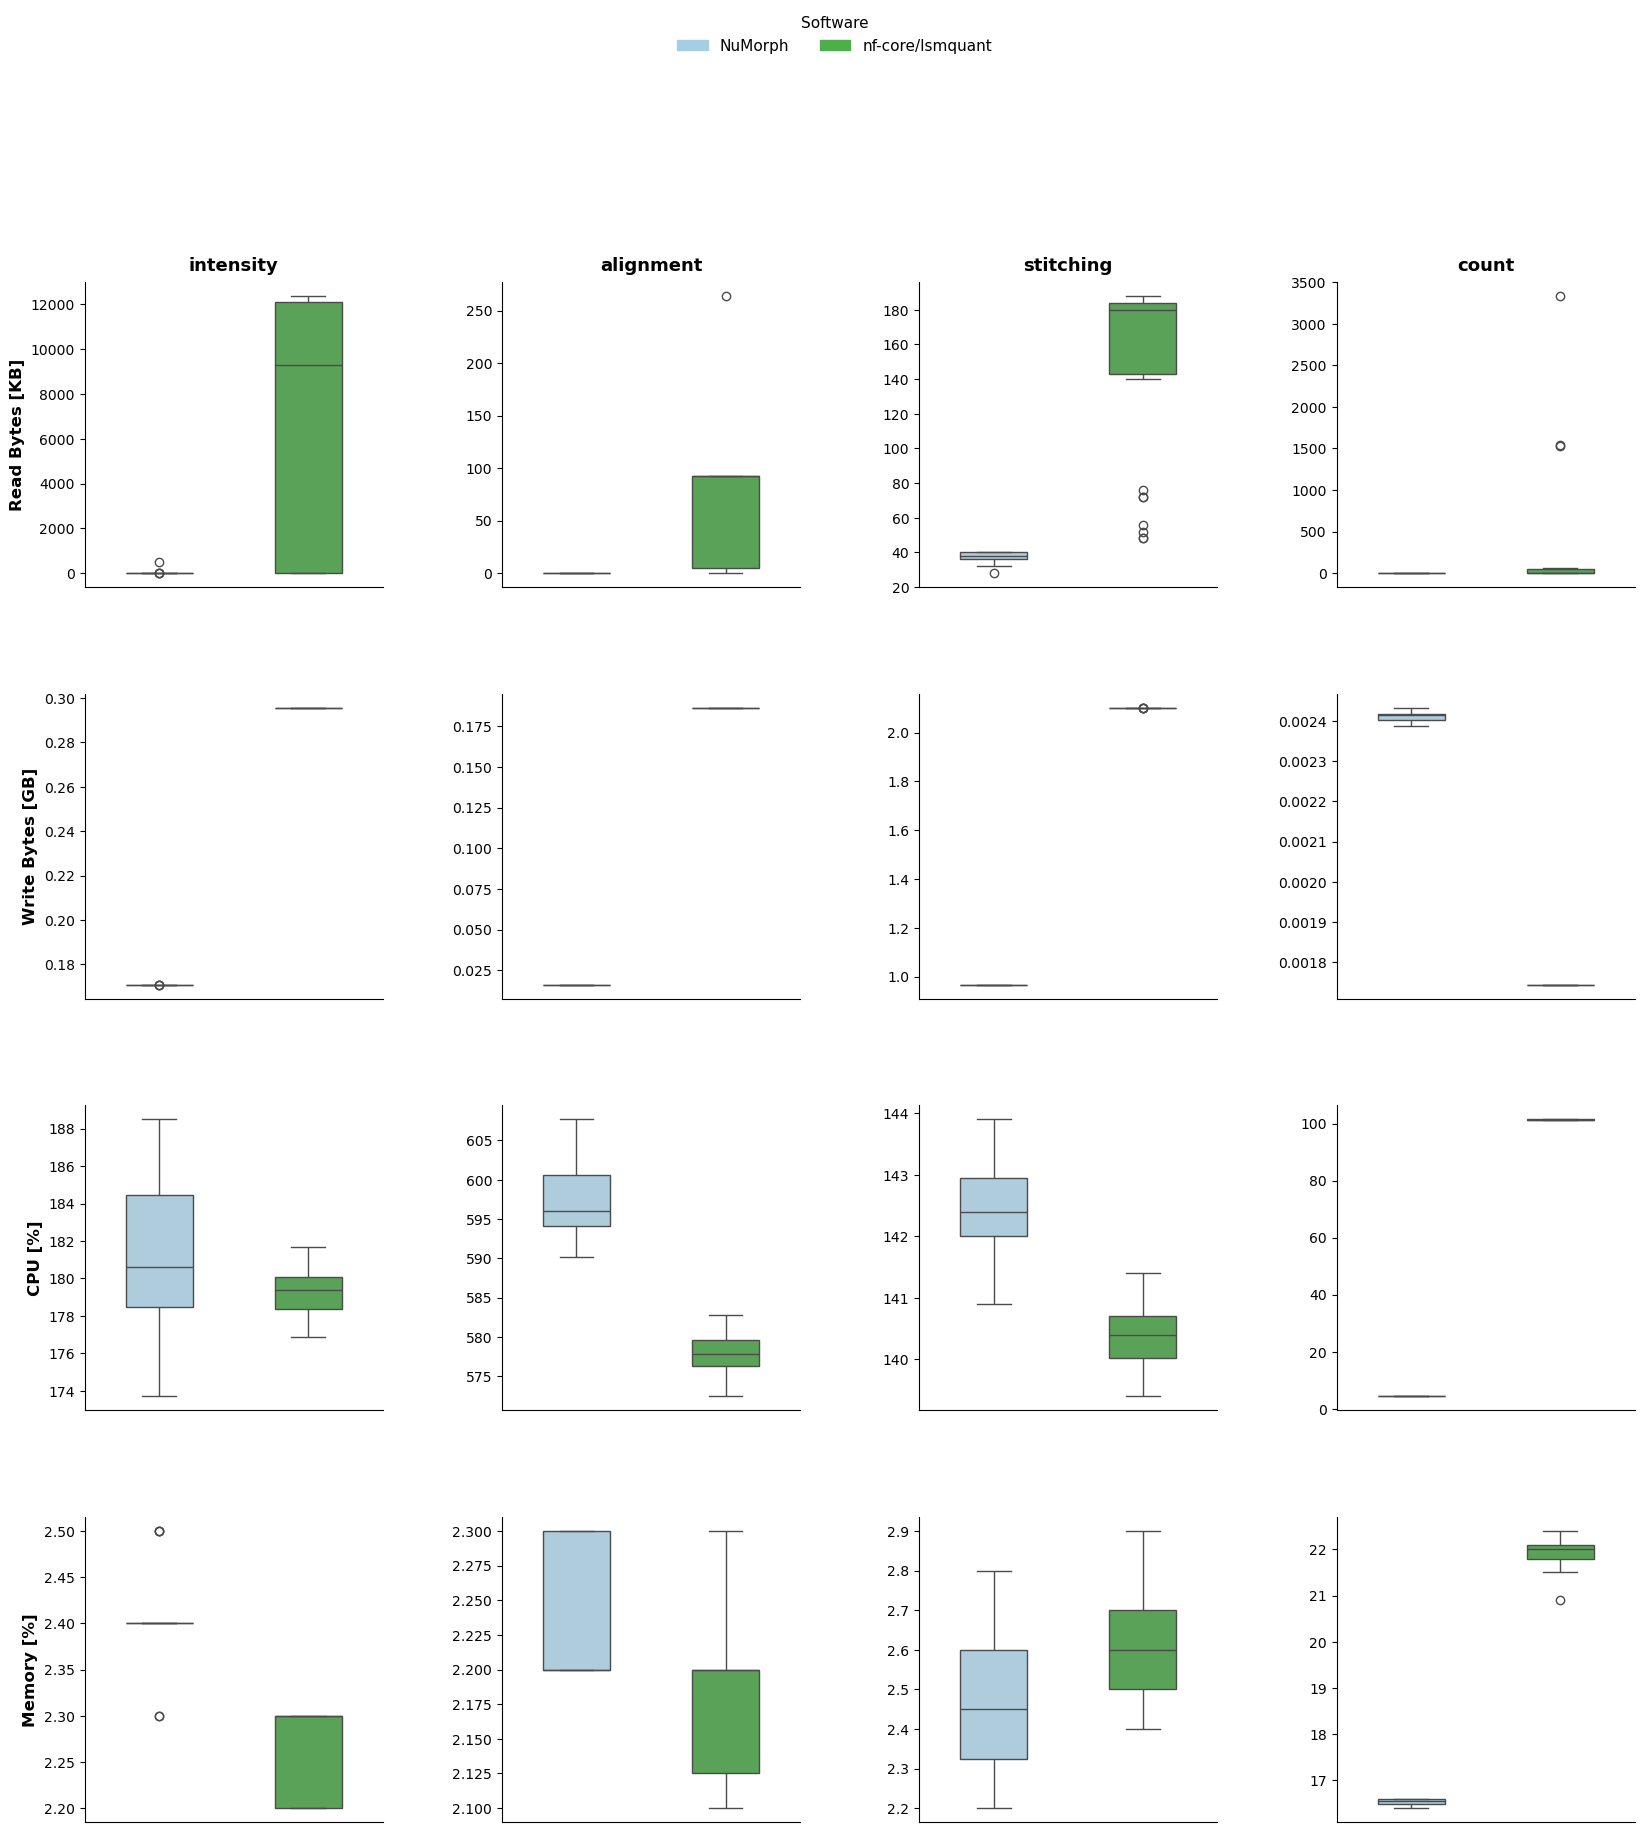

In [14]:

processes = benchmark_df['process'].unique()  # ['intensity', 'alignment', 'stitching', 'count']
metrics = [
    ("read_bytes",  "Read Bytes [KB]"),
    ("write_bytes",  "Write Bytes [GB]"),
    ("pcpu",  "CPU [%]"),
    ("pmem",  "Memory [%]"),
]

fig, axes = plt.subplots(
    nrows=4, ncols=4,
    figsize=(20, 20),
    gridspec_kw={"hspace": 0.35, "wspace": 0.4}
)

for row, (y_col, y_label) in enumerate(metrics):
    for col, process in enumerate(processes):
        ax = axes[row, col]

        df_sub = benchmark_df[benchmark_df['process'] == process]

        sns.boxplot(
            data=df_sub,
            x='software',
            y=y_col,
            hue='software',
            ax=ax,
            palette=palette,
            legend=False,
            gap=0.1,
            width=0.5,
        )

        # Title only on top row
        if row == 0:
            ax.set_title(process, fontsize=13, fontweight="bold", pad=8)

        # Y-axis label only on leftmost column
        if col == 0:
            ax.set_ylabel(y_label, fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.set_xticks([])  # remove x tick labels — legend handles software identity

        ax.tick_params(axis='y', labelsize=10)
        ax.spines[["top", "right"]].set_visible(False)

# Single shared legend — pull handles from any axis
handles = [
    plt.matplotlib.patches.Patch(color=palette[s], label=s)
    for s in benchmark_df['software'].unique()
]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=11,
    title_fontsize=11,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
)

fig.suptitle("")  # clear any auto title
plt.tight_layout()
plt.show()

### Scaling results

#### Plot scaling results

runtime for Numorph were taken from the runtime_summary.txt file file converted into minutes by dividing by 6000 manually
runtime for lsmquant were take from the pipeline report manually

In [19]:
matlab_process = {'n_samples': [1,2,3,4,5,6,7,8,9,10], 'duration [minutes]': [3.08, 6.12, 9.07, 12.19, 15.19, 18.32, 21.30, 24.46, 27.85, 30.71]}
nextflow_scaling_data = {'n_samples': [1,2,3,4,5,6,7,8,9,10], 'duration [minutes]': [4.75, 5.67, 7.57, 8.92, 10.92, 12.15, 14.23, 15.95, 17.80, 19.70]}

In [26]:
# scaling with count process 
numorph_process_all = {'n_samples': [1,2,3,4,5,6,7,8,9,10],  'duration [minutes]': [(3.08 + 2.93) , 
                                                                                    (6.12 +2.88 + 2.85), 
                                                                                    (9.07 + 2.88 + 2.92 + 2.84), 
                                                                                    (12.19 + 2.86 + 2.86 + 2.84 + 2.85), 
                                                                                    (15.19 + 2.83 + 2.88+ 2.90+ 2.84+2.89), 
                                                                                    (18.32 + 2.81 +2.84+ 2.81+ 2.85+ 2.75+ 2.90), 
                                                                                    (21.30 + 2.93+ 2.83+ 2.91+ 2.88+ 2.84+ 2.88+ 2.85), 
                                                                                    (24.46 + 2.92+ 2.88+ 2.86+ 2.86+ 2.86+ 2.88+ 2.81 + 2.83), 
                                                                                    (27.85 + 2.88 + 2.84 + 2.89 + 2.81 + 2.89 + 2.85+ 2.85 + 2.83 + 2.81), 
                                                                                    (30.71 + 2.91+ 2.81+ 2.87+ 2.89+ 2.80 + 2.88 + 2.88+ 2.84 + 2.77 + 2.83)]}
lsmquant_process_all = {'n_samples': [1,2,3,4,5,6,7,8,9,10], 'duration [minutes]': [21.1, 39.01, 55.57, 73.53,  91.67, 108.65, 126.42, 145.87, 163.13,180.9]}

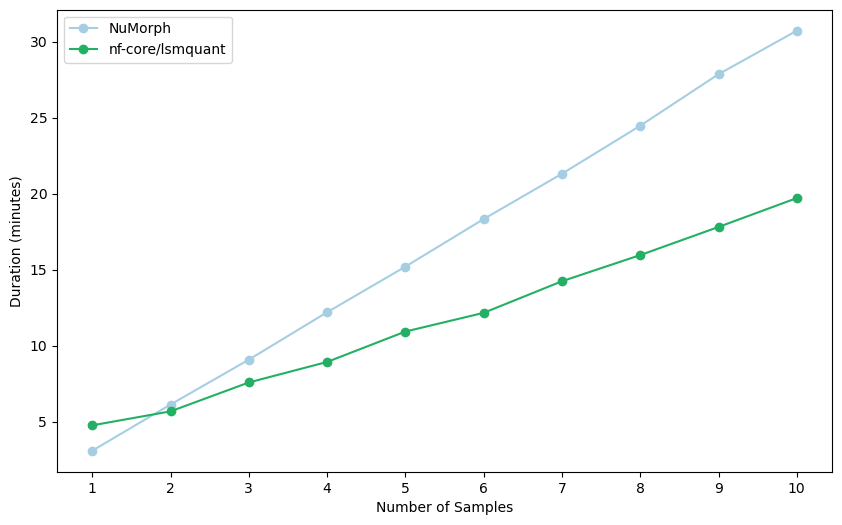

In [25]:
# plot the scaling results: x axis is n_samples and y axis is the duration in minutesfor numorph and nf-core/lsmquant
# show all x axis ticks
plt.figure(figsize=(10, 6))
plt.plot(matlab_process['n_samples'], matlab_process['duration [minutes]'], marker='o', label='NuMorph', color="#a6cee3")
plt.plot(nextflow_scaling_data['n_samples'], nextflow_scaling_data['duration [minutes]'], marker='o', label='nf-core/lsmquant', color="#24B064")
plt.xlabel('Number of Samples')
plt.xticks(matlab_process['n_samples'])  # Show all x-axis ticks
plt.ylabel('Duration (minutes)')
#plt.title('Scaling of Total Wall Time with Number of Samples')
plt.legend()
plt.savefig("scaling_preprocessing.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

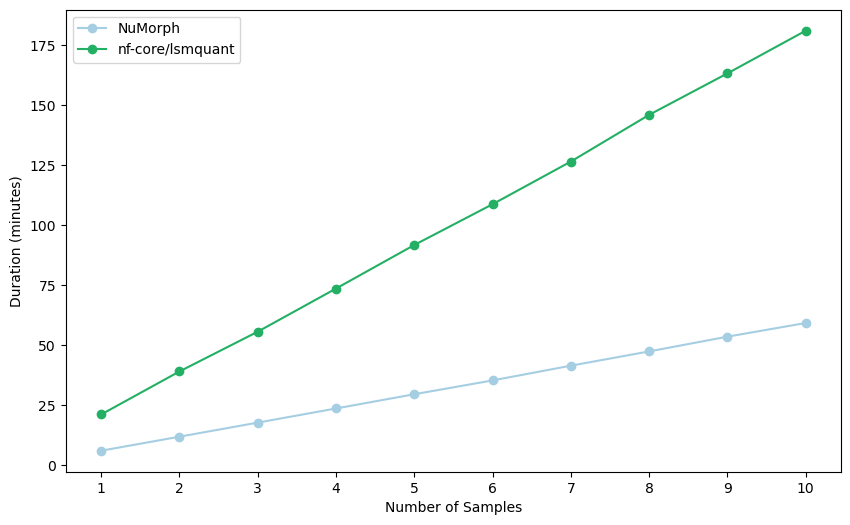

In [29]:
# plot scaling results with all processes

plt.figure(figsize=(10, 6))
plt.plot(numorph_process_all['n_samples'], numorph_process_all['duration [minutes]'], marker='o', label='NuMorph', color="#a6cee3")
plt.plot(lsmquant_process_all['n_samples'], lsmquant_process_all['duration [minutes]'], marker='o', label='nf-core/lsmquant', color="#24B064")
plt.xlabel('Number of Samples')
plt.xticks(numorph_process_all['n_samples'])  # Show all x-axis ticks
plt.ylabel('Duration (minutes)')
#plt.title('Scaling of Total Wall Time with Number of Samples')
plt.legend()
plt.savefig("scaling_all_processes.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

#### plot FAIRsoft score


In [23]:
FAIR_score = pd.DataFrame({
    'software': ['NuMorph', 'nf-core/lsmquant'],
    'Findability': [66, 100],
    'Accessability': [85, 85],
    'Interoperability': [82.7, 87.7],
    'Reusability': [70, 100]
})

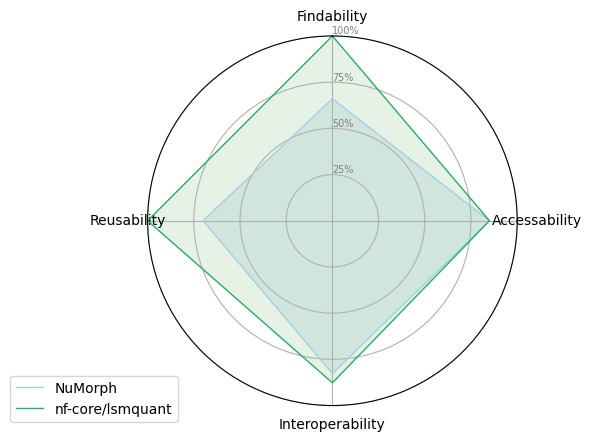

In [24]:
# ------- PART 1: Create background
 
# number of variable
categories=list(FAIR_score)[1:]
N = len(categories)
 
# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
 
# Initialise the spider plot
ax = plt.subplot(111, polar=True)
 
# If you want the first axis to be on top:
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
 
# Draw one axe per variable + add labels
plt.xticks(angles[:-1], categories)
 
# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([25,50,75,100], ["25%","50%","75%", "100%"], color="grey", size=7)
plt.ylim(0,100)
 

# ------- PART 2: Add plots
 
# Plot each individual = each line of the data
# I don't make a loop, because plotting more than 3 groups makes the chart unreadable
 
# Ind1
values=FAIR_score.loc[0].drop('software').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1, linestyle='solid', label="NuMorph", color="#a6cee3")
ax.fill(angles, values, 'o', alpha=0.1)
 
# Ind2
values=FAIR_score.loc[1].drop('software').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1, linestyle='solid', label="nf-core/lsmquant", color="#24B064")
ax.fill(angles, values, 'g', alpha=0.1)
 
# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# Show the graph
plt.show()